
---

**Paper:** *FISTA-Net: Learning A Fast Iterative Shrinkage Thresholding Network for Inverse Problems in Imaging*  
Xiang, Dong, Yang — IEEE Trans. Med. Imaging, 2021

---

### How this matches the paper:

| What | Paper (COMSOL) | This notebook (pyeit) |
|---|---|---|
| Sensitivity matrix A | FEM via COMSOL | FEM via pyeit (same physics) |
| Coils | 8 coils | 8 electrodes |
| Domain | Circular | Circular |
| Phantoms | 1–3 circular objects | 1–3 circular objects |
| Forward model | b = Ax + noise | b = Ax + noise |
| Noise | AWGN at 20/30/40 dB | AWGN at 20/30/40 dB |
| Output image | 64×64 grid | 64×64 grid |

### Pipeline:
```
FEM Mesh (pyeit) → Jacobian A → Random Phantom x → b = Ax + noise → Save .h5
```

---
## Cell 1 — Install libraries

In [ ]:
!pip install pyeit numpy scipy matplotlib h5py -q
print('✅ All libraries installed')

✅ All libraries installed


---
## Cell 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/FISTA_Net_EMT_Dataset'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅ Output folder: {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Output folder: /content/drive/MyDrive/FISTA_Net_EMT_Dataset


---
## Cell 3 — Imports

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import label

import pyeit.mesh as mesh
import pyeit.eit.protocol as protocol
import pyeit.eit.fem as fem

np.random.seed(42)
print('✅ Imports done')

✅ Imports done


---
## Cell 4 — Configuration

> These settings match Section IV-A of the FISTA-Net paper.

In [ ]:
# ── Dataset size ───────────────────────────────────────────
N_TRAIN      = 1000      # training samples (paper uses ~2000, reduce if slow)
N_TEST       = 200       # test samples

# ── EMT system (matches paper) ─────────────────────────────
N_COILS      = 8         # 8 coils around circular boundary
MESH_H0      = 0.04      # FEM mesh resolution (smaller = finer = slower)
DIST_EXC     = 1         # adjacent electrode excitation (standard)

# ── Image output ────────────────────────────────────────────
IMG_SIZE     = 64        # render FEM solution onto 64×64 pixel grid
DOMAIN_R     = 0.90      # circular domain radius (normalised to 1.0)

# ── Conductivity values (matches paper's biological tissue setup) ──
SIGMA_BG     = 1.0       # background conductivity  (S/m)
SIGMA_OBJ    = 3.0       # object conductivity      (S/m)
OBJ_R_MIN    = 0.12      # min object radius (normalised)
OBJ_R_MAX    = 0.28      # max object radius (normalised)

# ── Noise (paper tests at 20, 30, 40 dB) ───────────────────
NOISE_DB     = 30        # SNR in dB for generated dataset

print('✅ Configuration set')
print(f'   Samples : {N_TRAIN} train | {N_TEST} test')
print(f'   System  : {N_COILS} coils | mesh h0={MESH_H0}')
print(f'   Image   : {IMG_SIZE}×{IMG_SIZE} | domain_r={DOMAIN_R}')
print(f'   Physics : σ_bg={SIGMA_BG} S/m | σ_obj={SIGMA_OBJ} S/m')
print(f'   Noise   : {NOISE_DB} dB SNR')

✅ Configuration set
   Samples : 1000 train | 200 test
   System  : 8 coils | mesh h0=0.04
   Image   : 64×64 | domain_r=0.9
   Physics : σ_bg=1.0 S/m | σ_obj=3.0 S/m
   Noise   : 30 dB SNR


---
## Cell 5 — Build the FEM mesh and compute sensitivity matrix A

> **This is the key step** — `pyeit` uses the same Finite Element Method that the paper used in COMSOL.
> It solves the governing field equation numerically to compute how each element affects each measurement.
>
> `J[m, e]` = how much element `e`'s conductivity affects measurement `m`

In [ ]:
print('Step 1: Creating FEM mesh ...')
# Create circular FEM mesh with 8 electrodes on boundary
# n_el = number of electrodes, h0 = mesh element size
eit_mesh = mesh.create(n_el=N_COILS, h0=MESH_H0)

n_nodes    = eit_mesh.node.shape[0]
n_elements = eit_mesh.element.shape[0]
print(f'   Mesh: {n_nodes} nodes, {n_elements} triangular elements')

# ── Electrode positions on boundary ───────────────────────
el_pos_idx = eit_mesh.el_pos          # indices into node array
el_coords  = eit_mesh.node[el_pos_idx, :2]  # (8, 2) x,y coords
print(f'   Electrode positions (normalised circle):')
for i, (x, y) in enumerate(el_coords):
    print(f'     Coil {i+1}: ({x:+.3f}, {y:+.3f})')

print()
print('Step 2: Setting up measurement protocol ...')
# Adjacent excitation: coil i drives, coil i+1 is reference
# All other coil pairs measure voltage differences
eit_protocol = protocol.create(
    N_COILS,
    dist_exc   = DIST_EXC,   # distance between drive electrodes
    step_meas  = 1,           # step between measurement pairs
    parser_meas= 'std'        # standard adjacent measurement
)
N_MEAS = eit_protocol.n_exc * eit_protocol.n_meas
print(f'   Excitation patterns : {eit_protocol.n_exc}')
print(f'   Measurements each   : {eit_protocol.n_meas}')
print(f'   Total measurements  : {N_MEAS}')

print()
print('Step 3: Computing FEM Jacobian (sensitivity matrix A) ...')
print('   This is the physics-accurate equivalent of COMSOL sensitivity computation.')
# EITForward solves the Poisson equation for each excitation pattern
# and computes dV/dσ — how each conductivity element affects each voltage measurement
fwd_solver = fem.EITForward(eit_mesh, eit_protocol)

# J = Jacobian = sensitivity matrix  shape: (N_MEAS, n_elements)
# v0 = baseline voltages with homogeneous background
J, v0 = fwd_solver.compute_jac(
    perm      = SIGMA_BG * np.ones(n_elements),  # homogeneous background
    normalize = False
)
print(f'   Jacobian A shape: {J.shape}  ({N_MEAS} measurements × {n_elements} elements)')
print(f'   Baseline voltage v0 shape: {v0.shape}')

# Normalise rows of A (standard practice in EIT/EMT, also done in paper)
row_norms = np.linalg.norm(J, axis=1, keepdims=True) + 1e-12
A = J / row_norms
print(f'   Row-normalised A: done')

# Element centroids (x, y) — needed for phantom generation
CENTROIDS = eit_mesh.node[eit_mesh.element].mean(axis=1)[:, :2]  # (n_el, 2)

# Save A
np.save(f'{OUTPUT_DIR}/sensitivity_matrix_A.npy', A)
np.save(f'{OUTPUT_DIR}/baseline_voltages_v0.npy', v0)
np.save(f'{OUTPUT_DIR}/element_centroids.npy', CENTROIDS)
np.save(f'{OUTPUT_DIR}/electrode_coords.npy', el_coords)
print(f'\n✅ Sensitivity matrix A saved  →  {OUTPUT_DIR}/sensitivity_matrix_A.npy')

Step 1: Creating FEM mesh ...
   Mesh: 2292 nodes, 4422 triangular elements
   Electrode positions (normalised circle):
     Coil 1: (-1.000, +0.000)
     Coil 2: (-0.707, +0.707)
     Coil 3: (-0.000, +1.000)
     Coil 4: (+0.707, +0.707)
     Coil 5: (+1.000, +0.000)
     Coil 6: (+0.707, -0.707)
     Coil 7: (+0.000, -1.000)
     Coil 8: (-0.707, -0.707)

Step 2: Setting up measurement protocol ...
   Excitation patterns : 8
   Measurements each   : 5
   Total measurements  : 40

Step 3: Computing FEM Jacobian (sensitivity matrix A) ...
   This is the physics-accurate equivalent of COMSOL sensitivity computation.
   Jacobian A shape: (40, 4422)  (40 measurements × 4422 elements)
   Baseline voltage v0 shape: (40,)
   Row-normalised A: done

✅ Sensitivity matrix A saved  →  /content/drive/MyDrive/FISTA_Net_EMT_Dataset/sensitivity_matrix_A.npy


---
## Cell 6 — Visualise the FEM mesh and sensitivity map

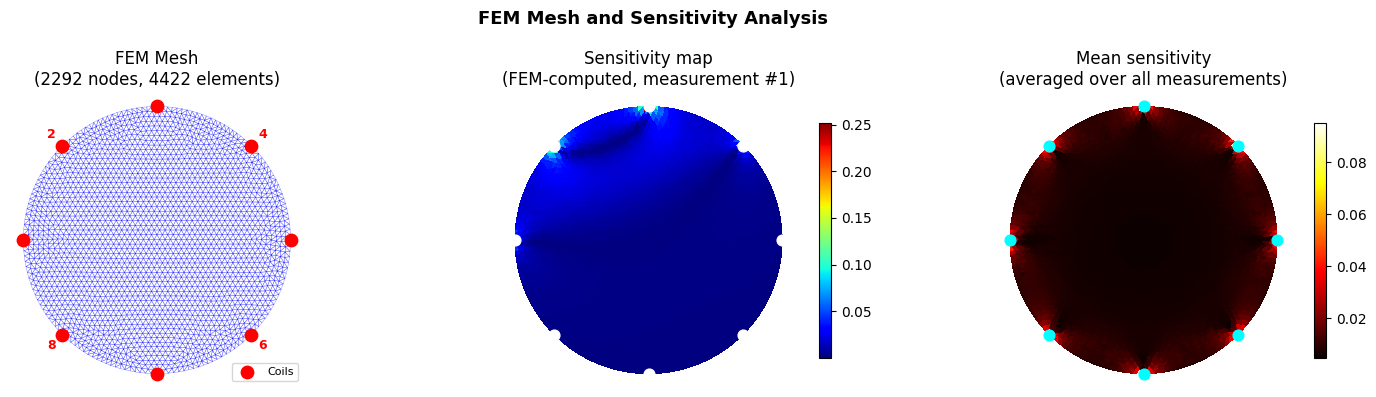

✅ Saved fem_mesh_sensitivity.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('FEM Mesh and Sensitivity Analysis', fontsize=13, fontweight='bold')

# ── Plot 1: FEM mesh ──────────────────────────────────────
ax = axes[0]
nodes_2d = eit_mesh.node[:, :2]
for tri in eit_mesh.element:
    pts = nodes_2d[np.append(tri, tri[0])]
    ax.plot(pts[:, 0], pts[:, 1], 'b-', lw=0.3, alpha=0.5)
ax.scatter(el_coords[:, 0], el_coords[:, 1],
           c='red', s=80, zorder=5, label='Coils')
for i, (x, y) in enumerate(el_coords):
    ax.annotate(f'{i+1}', (x*1.12, y*1.12), ha='center', va='center',
                fontsize=9, color='red', fontweight='bold')
ax.set_aspect('equal')
ax.set_title(f'FEM Mesh\n({n_nodes} nodes, {n_elements} elements)')
ax.legend(loc='lower right', fontsize=8)
ax.axis('off')

# ── Plot 2: Sensitivity map for measurement 0 ────────────
ax = axes[1]
sens_map = np.abs(A[0])  # sensitivity of first measurement
scatter = ax.tripcolor(
    nodes_2d[:, 0], nodes_2d[:, 1],
    eit_mesh.element,
    facecolors=sens_map,
    cmap='jet'
)
ax.scatter(el_coords[:, 0], el_coords[:, 1], c='white', s=60, zorder=5)
ax.set_aspect('equal')
ax.set_title('Sensitivity map\n(FEM-computed, measurement #1)')
plt.colorbar(scatter, ax=ax, shrink=0.8)
ax.axis('off')

# ── Plot 3: Average sensitivity across all measurements ───
ax = axes[2]
mean_sens = np.abs(A).mean(axis=0)
scatter2 = ax.tripcolor(
    nodes_2d[:, 0], nodes_2d[:, 1],
    eit_mesh.element,
    facecolors=mean_sens,
    cmap='hot'
)
ax.scatter(el_coords[:, 0], el_coords[:, 1], c='cyan', s=60, zorder=5)
ax.set_aspect('equal')
ax.set_title('Mean sensitivity\n(averaged over all measurements)')
plt.colorbar(scatter2, ax=ax, shrink=0.8)
ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fem_mesh_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved fem_mesh_sensitivity.png')

---
## Cell 7 — Phantom generator

> Generates random conductivity maps on the FEM mesh — 1, 2, or 3 circular conductive objects,
> then renders them onto a regular 64×64 pixel grid (same as paper).

In [ ]:
# ── Precompute pixel grid ────────────────────────────────────
xi = np.linspace(-1, 1, IMG_SIZE)
yi = np.linspace(-1, 1, IMG_SIZE)
XX, YY = np.meshgrid(xi, yi)
DOMAIN_MASK = (XX**2 + YY**2) <= DOMAIN_R**2  # circular sensing region

def make_phantom():
    """
    Generate a random phantom with 1–3 circular conductive objects.

    Returns
    -------
    perm_elem : np.ndarray (n_elements,)
        Conductivity values on FEM mesh elements.
    img_64 : np.ndarray (64, 64)
        Conductivity contrast rendered to pixel grid.
    n_placed : int
        Actual number of objects placed.
    """
    n_objects = np.random.randint(1, 4)          # 1, 2, or 3 objects
    perm_elem = SIGMA_BG * np.ones(n_elements)   # start with background
    placed    = []
    attempts  = 0

    while len(placed) < n_objects and attempts < 300:
        attempts += 1
        # Random object radius
        r = np.random.uniform(OBJ_R_MIN, OBJ_R_MAX)
        # Object centre must stay inside domain
        margin     = r + 0.04
        max_center = DOMAIN_R - margin
        if max_center <= 0:
            continue
        # Random position
        angle = np.random.uniform(0, 2 * np.pi)
        dist  = np.random.uniform(0, max_center)
        cx    = dist * np.cos(angle)
        cy    = dist * np.sin(angle)
        # Check overlap with already-placed objects
        overlap = any(
            np.sqrt((cx - px)**2 + (cy - py)**2) < (r + pr + 0.03)
            for (px, py, pr) in placed
        )
        if overlap:
            continue
        # Mark FEM elements inside this circle as conductive
        in_circle = (CENTROIDS[:, 0] - cx)**2 + (CENTROIDS[:, 1] - cy)**2 <= r**2
        perm_elem[in_circle] = SIGMA_OBJ
        placed.append((cx, cy, r))

    # ── Render FEM element values onto 64×64 pixel grid ────
    # Use griddata to interpolate element-centroid values to regular grid
    delta_perm = perm_elem - SIGMA_BG          # conductivity CONTRAST
    img_64 = griddata(
        CENTROIDS, delta_perm,
        (XX, YY),
        method     = 'linear',
        fill_value = 0.0
    )
    img_64[~DOMAIN_MASK] = 0.0                 # zero outside domain
    img_64 = img_64.astype(np.float32)

    return perm_elem, img_64, len(placed)


def add_noise(signal, snr_db):
    """Add white Gaussian noise to achieve target SNR in dB."""
    power = np.mean(signal ** 2)
    snr   = 10 ** (snr_db / 10.0)
    std   = np.sqrt(power / (snr + 1e-12))
    return signal + np.random.randn(*signal.shape) * std


# Quick sanity check
np.random.seed(0)
perm_test, img_test, n_test = make_phantom()
v1_test = fwd_solver.solve_eit(perm=perm_test)
b_test  = add_noise(v1_test - v0, NOISE_DB)

print('✅ Phantom generator ready')
print(f'   perm_elem shape : {perm_test.shape}')
print(f'   image shape     : {img_test.shape}')
print(f'   measurement b   : {b_test.shape}')
print(f'   objects placed  : {n_test}')

✅ Phantom generator ready
   perm_elem shape : (4422,)
   image shape     : (64, 64)
   measurement b   : (40,)
   objects placed  : 1


---
## Cell 8 — Generate the full dataset and save to Drive

In [ ]:
def generate_split(n_samples, split_name, noise_db=NOISE_DB):
    """
    Generate n_samples EMT phantoms and their noisy measurements.
    Saves to HDF5 file in Google Drive.
    """
    print(f'\nGenerating {split_name} set  ({n_samples} samples, SNR={noise_db} dB) ...')

    images    = np.zeros((n_samples, IMG_SIZE, IMG_SIZE), dtype=np.float32)
    meas      = np.zeros((n_samples, N_MEAS),            dtype=np.float32)
    n_obj_log = np.zeros(n_samples,                       dtype=np.int32)

    for i in range(n_samples):
        # 1. Generate random phantom on FEM mesh
        perm_elem, img_64, n_obj = make_phantom()

        # 2. Solve forward problem with FEM: get voltages for this perm
        #    b = A·Δσ  is the linearised model
        #    We use the full nonlinear FEM forward to get v1, then take Δv = v1 - v0
        v1      = fwd_solver.solve_eit(perm=perm_elem)
        b_clean = v1 - v0                          # differential measurement

        # 3. Add Gaussian noise at target SNR
        b_noisy = add_noise(b_clean, noise_db)

        # 4. Store
        images[i]    = img_64
        meas[i]      = b_noisy.astype(np.float32)
        n_obj_log[i] = n_obj

        if (i + 1) % 100 == 0:
            print(f'  [{i+1:4d}/{n_samples}]  1-obj: {(n_obj_log[:i+1]==1).sum()}  '
                  f'2-obj: {(n_obj_log[:i+1]==2).sum()}  '
                  f'3-obj: {(n_obj_log[:i+1]==3).sum()}')

    # Save to HDF5
    h5_path = f'{OUTPUT_DIR}/emt_{split_name}.h5'
    with h5py.File(h5_path, 'w') as f:
        # Core data
        f.create_dataset('images',       data=images,    compression='gzip', compression_opts=4)
        f.create_dataset('measurements', data=meas,      compression='gzip', compression_opts=4)
        f.create_dataset('n_objects',    data=n_obj_log)

        # Metadata
        f.attrs['description']  = 'Synthetic EMT dataset for FISTA-Net (FEM-based, pyeit)'
        f.attrs['n_samples']    = n_samples
        f.attrs['img_size']     = IMG_SIZE
        f.attrs['n_coils']      = N_COILS
        f.attrs['n_meas']       = N_MEAS
        f.attrs['noise_db']     = noise_db
        f.attrs['sigma_bg']     = SIGMA_BG
        f.attrs['sigma_obj']    = SIGMA_OBJ
        f.attrs['mesh_h0']      = MESH_H0
        f.attrs['n_elements']   = n_elements

    size_mb = os.path.getsize(h5_path) / 1e6
    print(f'\n  ✅ Saved → {h5_path}  ({size_mb:.1f} MB)')
    return images, meas, n_obj_log


train_imgs, train_meas, train_nobj = generate_split(N_TRAIN, 'train')
test_imgs,  test_meas,  test_nobj  = generate_split(N_TEST,  'test')


Generating train set  (1000 samples, SNR=30 dB) ...
  [ 100/1000]  1-obj: 29  2-obj: 39  3-obj: 32
  [ 200/1000]  1-obj: 64  2-obj: 70  3-obj: 66
  [ 300/1000]  1-obj: 102  2-obj: 99  3-obj: 99
  [ 400/1000]  1-obj: 136  2-obj: 141  3-obj: 123
  [ 500/1000]  1-obj: 174  2-obj: 174  3-obj: 152
  [ 600/1000]  1-obj: 206  2-obj: 207  3-obj: 187
  [ 700/1000]  1-obj: 237  2-obj: 236  3-obj: 227
  [ 800/1000]  1-obj: 270  2-obj: 265  3-obj: 265
  [ 900/1000]  1-obj: 301  2-obj: 302  3-obj: 297
  [1000/1000]  1-obj: 327  2-obj: 346  3-obj: 327

  ✅ Saved → /content/drive/MyDrive/FISTA_Net_EMT_Dataset/emt_train.h5  (0.6 MB)

Generating test set  (200 samples, SNR=30 dB) ...
  [ 100/200]  1-obj: 37  2-obj: 30  3-obj: 33
  [ 200/200]  1-obj: 68  2-obj: 64  3-obj: 68

  ✅ Saved → /content/drive/MyDrive/FISTA_Net_EMT_Dataset/emt_test.h5  (0.2 MB)


---
## Cell 9 — Visualise sample phantoms (like Figure 3 in the paper)

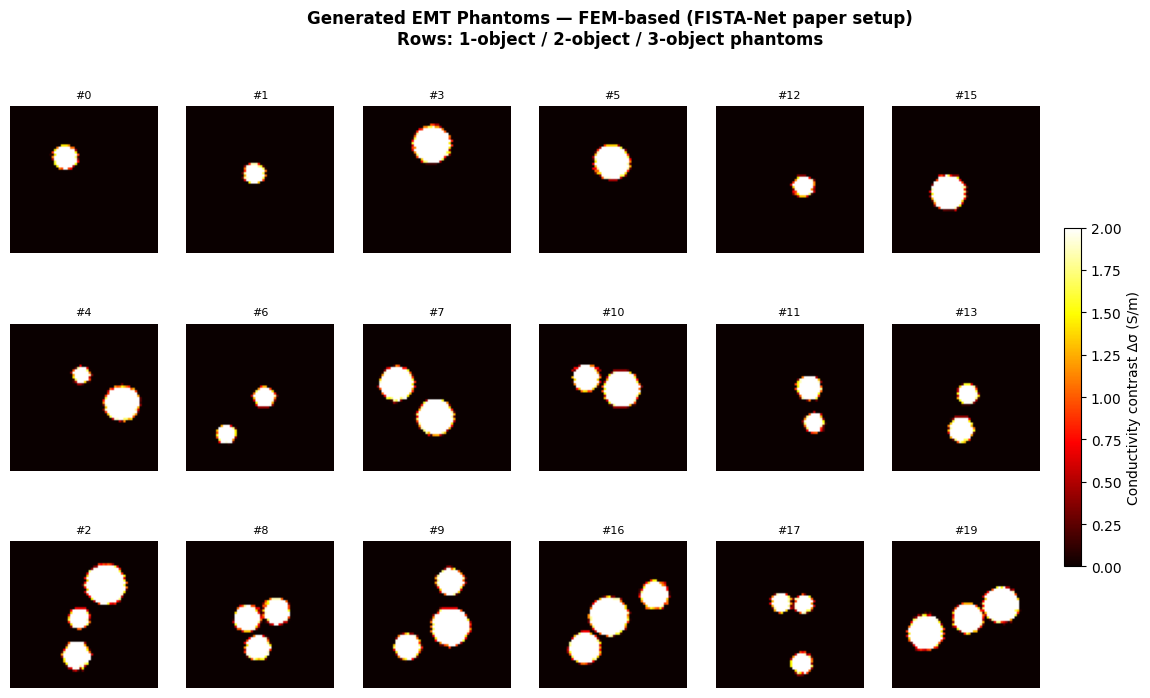

✅ Saved sample_phantoms.png


In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle(
    'Generated EMT Phantoms — FEM-based (FISTA-Net paper setup)\n'
    'Rows: 1-object / 2-object / 3-object phantoms',
    fontsize=12, fontweight='bold'
)

# Collect 6 examples of each class
groups = {1: [], 2: [], 3: []}
for i in range(N_TRAIN):
    n = train_nobj[i]
    if n in groups and len(groups[n]) < 6:
        groups[n].append(i)
    if all(len(v) == 6 for v in groups.values()):
        break

for row, n_obj in enumerate([1, 2, 3]):
    for col, idx in enumerate(groups[n_obj]):
        ax = axes[row, col]
        im = ax.imshow(
            train_imgs[idx],
            cmap='hot',
            vmin=0,
            vmax=SIGMA_OBJ - SIGMA_BG,
            origin='lower'
        )
        ax.set_title(f'#{idx}', fontsize=8)
        ax.axis('off')
    axes[row, 0].set_ylabel(f'{n_obj} object(s)', fontsize=11, labelpad=10)

cbar = plt.colorbar(im, ax=axes, label='Conductivity contrast Δσ (S/m)',
                    shrink=0.55, pad=0.02)
plt.savefig(f'{OUTPUT_DIR}/sample_phantoms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved sample_phantoms.png')

---
## Cell 10 — Dataset statistics

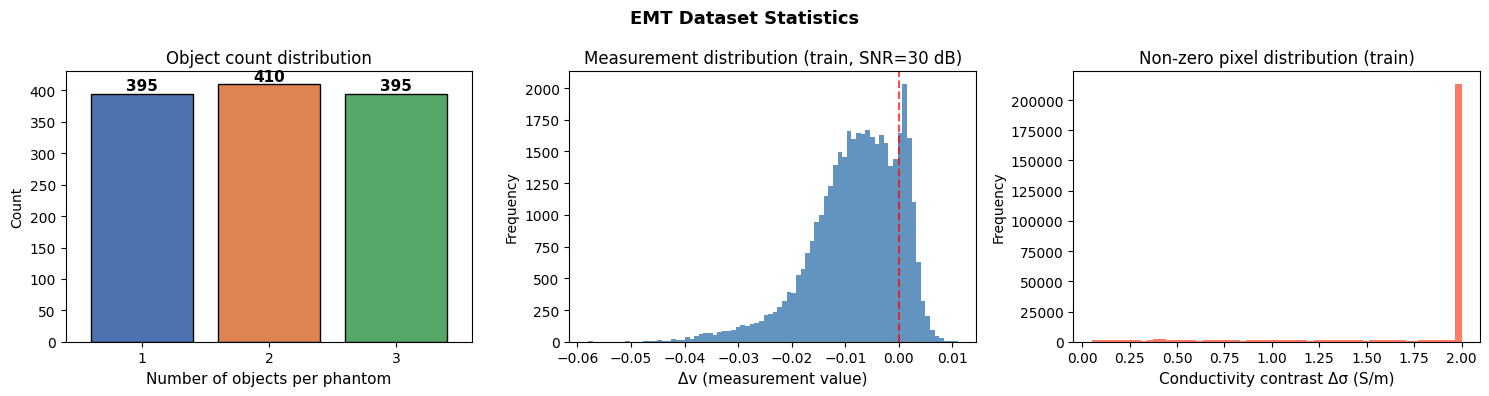

✅ Saved dataset_statistics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EMT Dataset Statistics', fontsize=13, fontweight='bold')

# Object count distribution
all_nobj = np.concatenate([train_nobj, test_nobj])
counts   = [np.sum(all_nobj == k) for k in [1, 2, 3]]
bars = axes[0].bar([1, 2, 3], counts,
                   color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of objects per phantom', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].set_title('Object count distribution')
axes[0].set_xticks([1, 2, 3])
axes[0].set_xlim(0.4, 3.6)

# Measurement signal distribution
axes[1].hist(train_meas.flatten(), bins=80, color='steelblue', alpha=0.85, edgecolor='none')
axes[1].set_xlabel('Δv (measurement value)', fontsize=11)
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Measurement distribution (train, SNR={NOISE_DB} dB)')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--', alpha=0.7)

# Non-zero pixel conductivity distribution
nonzero_vals = train_imgs[train_imgs > 0.05].flatten()
axes[2].hist(nonzero_vals, bins=60, color='tomato', alpha=0.85, edgecolor='none')
axes[2].set_xlabel('Conductivity contrast Δσ (S/m)', fontsize=11)
axes[2].set_ylabel('Frequency')
axes[2].set_title('Non-zero pixel distribution (train)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved dataset_statistics.png')

---
## Cell 11 — Verify saved files and show how to load

In [ ]:
print('=' * 55)
print('  EMT DATASET GENERATION COMPLETE')
print('=' * 55)

print(f'\nFiles in {OUTPUT_DIR}:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath   = os.path.join(OUTPUT_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<42s}  {size_mb:6.2f} MB')

print()
print('Dataset summary:')
print(f'  Training samples    : {N_TRAIN}')
print(f'  Test samples        : {N_TEST}')
print(f'  Image shape         : ({IMG_SIZE}, {IMG_SIZE})')
print(f'  Measurement shape   : ({N_MEAS},)')
print(f'  Sensitivity A shape : ({N_MEAS}, {n_elements})')
print(f'  FEM elements        : {n_elements}')
print(f'  SNR                 : {NOISE_DB} dB')

print()
print('─' * 55)
print('HOW TO LOAD IN YOUR TRAINING SCRIPT:')
print('─' * 55)
print('''
import h5py
import numpy as np

# Load training data
with h5py.File('emt_train.h5', 'r') as f:
    images = f['images'][:]        # (1000, 64, 64)  ground truth
    meas   = f['measurements'][:]  # (1000, 40)      noisy measurements
    n_objs = f['n_objects'][:]     # (1000,)         object count

# Load sensitivity matrix
A = np.load('sensitivity_matrix_A.npy')  # (40, n_elements)

# For FISTA-Net training:
#   Input  → meas[i]   shape (40,)      — measurements b
#   Target → images[i] shape (64, 64)   — ground truth x
#   Matrix → A         shape (40, M)    — used inside network
''')

# Final verification
with h5py.File(f'{OUTPUT_DIR}/emt_train.h5', 'r') as f:
    print('Verification of saved file:')
    print(f"  images shape      : {f['images'].shape}")
    print(f"  measurements shape: {f['measurements'].shape}")
    print(f"  n_objects range   : {f['n_objects'][:].min()} – {f['n_objects'][:].max()}")
    for k, v in f.attrs.items():
        print(f'  attr {k:<18s}: {v}')

print('\n✅ All done! Dataset ready for FISTA-Net training.')

  EMT DATASET GENERATION COMPLETE

Files in /content/drive/MyDrive/FISTA_Net_EMT_Dataset:
  baseline_voltages_v0.npy                      0.00 MB
  dataset_statistics.png                        0.10 MB
  electrode_coords.npy                          0.00 MB
  element_centroids.npy                         0.07 MB
  emt_test.h5                                   0.15 MB
  emt_train.h5                                  0.59 MB
  fem_mesh_sensitivity.png                      0.32 MB
  sample_phantoms.png                           0.07 MB
  sensitivity_matrix_A.npy                      1.42 MB

Dataset summary:
  Training samples    : 1000
  Test samples        : 200
  Image shape         : (64, 64)
  Measurement shape   : (40,)
  Sensitivity A shape : (40, 4422)
  FEM elements        : 4422
  SNR                 : 30 dB

───────────────────────────────────────────────────────
HOW TO LOAD IN YOUR TRAINING SCRIPT:
───────────────────────────────────────────────────────

import h5py
import nump